2026-02-25 20:28:11,040 - pyswarms.single.global_best - INFO - Optimize for 2 iters with {'c1': 0.3, 'c2': 0.2, 'w': 0.7}
pyswarms.single.global_best: 100%|██████████|2/2, best_cost=0.00642
2026-02-25 20:32:35,618 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.006416158361146285, best pos: [0.00177114 0.40721712]


Best ChOA Params: (0.0011300630138563342, 0.3521246625902915)
Best PSO Params: [0.00177114 0.40721712]
Classification Report - Ensemble
                         precision    recall  f1-score   support

 DDoS-ACK_Fragmentation       1.00      0.96      0.98       299
        DDoS-HTTP_Flood       0.94      0.84      0.89        37
        DDoS-ICMP_Flood       1.00      1.00      1.00      7353
DDoS-ICMP_Fragmentation       0.98      0.98      0.98       491
      DDoS-PSHACK_Flood       1.00      1.00      1.00      4243
       DDoS-RSTFINFlood       1.00      1.00      1.00      4030
         DDoS-SYN_Flood       1.00      0.99      0.99      4028
         DDoS-SlowLoris       0.22      0.77      0.34        13
DDoS-SynonymousIP_Flood       0.99      1.00      0.99      3744
         DDoS-TCP_Flood       1.00      1.00      1.00      4641
         DDoS-UDP_Flood       1.00      1.00      1.00      5576
 DDoS-UDP_Fragmentation       0.97      0.97      0.97       301

               ac

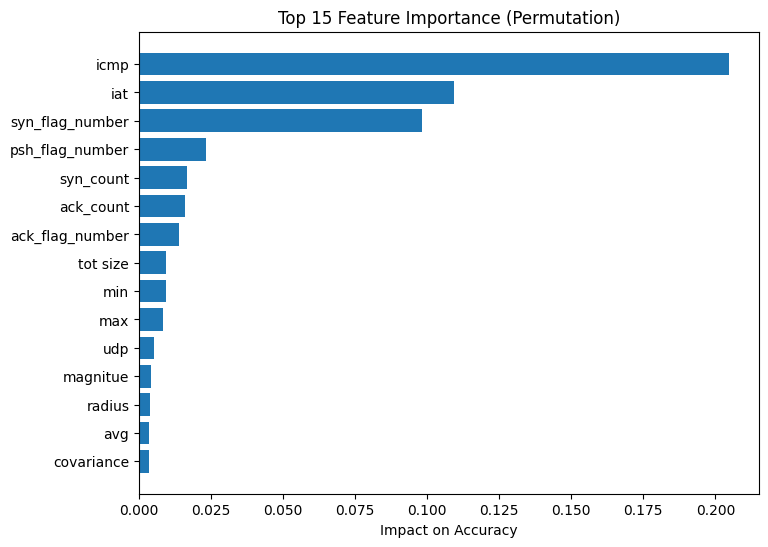

In [ ]:

# 0. Install Required Library

!pip install pyswarms

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pyswarms as ps

# 1. Load Dataset

df = pd.read_csv("/content/sample_data/DDoS_part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv")

# Convert all column names to lowercase to avoid case sensitivity issues
df.columns = df.columns.str.lower()

# Encode categorical columns
for col in df.select_dtypes(include=['object']).columns:
    if col != "label": # Changed to lowercase 'label'
        df[col] = LabelEncoder().fit_transform(df[col])

# Encode target column
le = LabelEncoder()
df["label"] = le.fit_transform(df["label"]) # Changed to lowercase 'label'

feature_names = df.drop("label", axis=1).columns # Changed to lowercase 'label'

X = df.drop("label", axis=1).values # Changed to lowercase 'label'
y = df["label"].values # Changed to lowercase 'label'

# Clean data
X[np.isinf(X)] = np.nan
X = np.nan_to_num(X, nan=0.0)

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Reshape for CNN
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

n_classes = len(np.unique(y))


# 2. CNN Model Builder (Fixed Warning)

def create_cnn(learning_rate=0.0015, dropout_rate=0.4):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1], 1)),

        tf.keras.layers.Conv1D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Dropout(dropout_rate),

        tf.keras.layers.Conv1D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Dropout(dropout_rate),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 3. ChOA Optimization

def chao_optimize():
    best_acc = 0
    best_params = None

    for _ in range(6):
        lr = random.uniform(0.001, 0.002)
        dr = random.uniform(0.35, 0.45)

        model = create_cnn(lr, dr)
        model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)

        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred)

        if acc > best_acc:
            best_acc = acc
            best_params = (lr, dr)

    return best_params


# 4. PSO Optimization

def fitness_function(params):
    lr, dr = params
    model = create_cnn(lr, dr)
    model.fit(X_train, y_train, epochs=2, batch_size=32, verbose=0)
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    return 1 - accuracy_score(y_test, y_pred)

bounds = ([0.001, 0.3], [0.002, 0.5])

def pso_optimize():
    optimizer = ps.single.GlobalBestPSO(
        n_particles=2,
        dimensions=2,
        options={'c1': 0.3, 'c2': 0.2, 'w': 0.7},
        bounds=bounds
    )
    cost, pos = optimizer.optimize(
        lambda x: np.array([fitness_function(p) for p in x]),
        iters=2
    )
    return pos


# 5. Run Optimization

chao_params = chao_optimize()
pso_params = pso_optimize()

print("Best ChOA Params:", chao_params)
print("Best PSO Params:", pso_params)


# 6. Train Final Models

cnn_chao = create_cnn(*chao_params)
cnn_chao.fit(X_train, y_train, epochs=8, batch_size=32, verbose=0)

cnn_pso = create_cnn(*pso_params)
cnn_pso.fit(X_train, y_train, epochs=4, batch_size=32, verbose=0)

# Predictions
y_pred_chao_proba = cnn_chao.predict(X_test, verbose=0)
y_pred_chao = np.argmax(y_pred_chao_proba, axis=1)

y_pred_pso_proba = cnn_pso.predict(X_test, verbose=0)
y_pred_pso = np.argmax(y_pred_pso_proba, axis=1)


# 7. Weighted Ensemble

acc_chao = accuracy_score(y_test, y_pred_chao)
acc_pso = accuracy_score(y_test, y_pred_pso)

w_chao = acc_chao / (acc_chao + acc_pso)
w_pso = acc_pso / (acc_chao + acc_pso)

y_pred_ensemble_proba = (
    w_chao * y_pred_chao_proba + w_pso * y_pred_pso_proba
)
y_pred_ensemble = np.argmax(y_pred_ensemble_proba, axis=1)

# 8. Print Metrics

print("Classification Report - Ensemble")
print(classification_report(y_test, y_pred_ensemble, target_names=le.classes_))


# 9. Feature Importance (Permutation)

# Flatten test data
X_test_flat = X_test.reshape(X_test.shape[0], X_test.shape[1])

def cnn_wrapper(X):
    X_r = X.reshape((X.shape[0], X.shape[1], 1))
    return np.argmax(cnn_chao.predict(X_r, verbose=0), axis=1)

# Custom estimator wrapper
class ModelWrapper:
    def fit(self, X, y): pass
    def predict(self, X): return cnn_wrapper(X)

wrapper = ModelWrapper()

result = permutation_importance(
    wrapper,
    X_test_flat,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

print("\nTop 15 Important Features:")
print(importance_df.head(15))

# Plot
plt.figure(figsize=(8,6))
plt.barh(
    importance_df.head(15)["Feature"],
    importance_df.head(15)["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importance (Permutation)")
plt.xlabel("Impact on Accuracy")
plt.show()


# 10. Save Model

cnn_chao.save("cnn_chao_ddos.keras")

2026-02-25 21:55:14,149 - pyswarms.single.global_best - INFO - Optimize for 2 iters with {'c1': 0.3, 'c2': 0.2, 'w': 0.7}
pyswarms.single.global_best: 100%|██████████|2/2, best_cost=0.0206
2026-02-25 22:10:43,377 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.02063170095624456, best pos: [0.00177229 0.43267115]


Best ChOA Params: (0.001236365379180688, 0.3546091786329227)
Best PSO Params: [0.00177229 0.43267115]
Classification Report - Ensemble
               precision    recall  f1-score   support

       Benign       0.99      1.00      0.99     19619
    DrDoS_DNS       0.90      0.86      0.88       748
   DrDoS_LDAP       0.59      0.98      0.73       263
  DrDoS_MSSQL       0.93      0.96      0.94      1215
    DrDoS_NTP       1.00      0.99      1.00     24300
DrDoS_NetBIOS       0.76      0.64      0.70       112
   DrDoS_SNMP       1.00      0.73      0.84       557
    DrDoS_UDP       1.00      0.99      1.00      2085
         LDAP       0.92      0.95      0.94       375
        MSSQL       0.96      0.96      0.96      1726
      NetBIOS       0.96      0.96      0.96       112
      Portmap       0.80      0.65      0.71       124
          Syn       1.00      0.99      0.99      9847
         TFTP       1.00      1.00      1.00     19869
          UDP       0.87      0.98     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Top 15 Important Features:
                   Feature  Importance
0               unnamed: 0    0.216035
1                 protocol    0.044483
66      init fwd win bytes    0.022741
68    fwd act data packets    0.016668
2            flow duration    0.009873
53         avg packet size    0.003825
37           fwd packets/s    0.001653
67      init bwd win bytes    0.001484
7    fwd packet length max    0.001426
12   bwd packet length min    0.001256
48          ack flag count    0.001092
49          urg flag count    0.001013
40       packet length max    0.000749
9   fwd packet length mean    0.000679
52           down/up ratio    0.000614


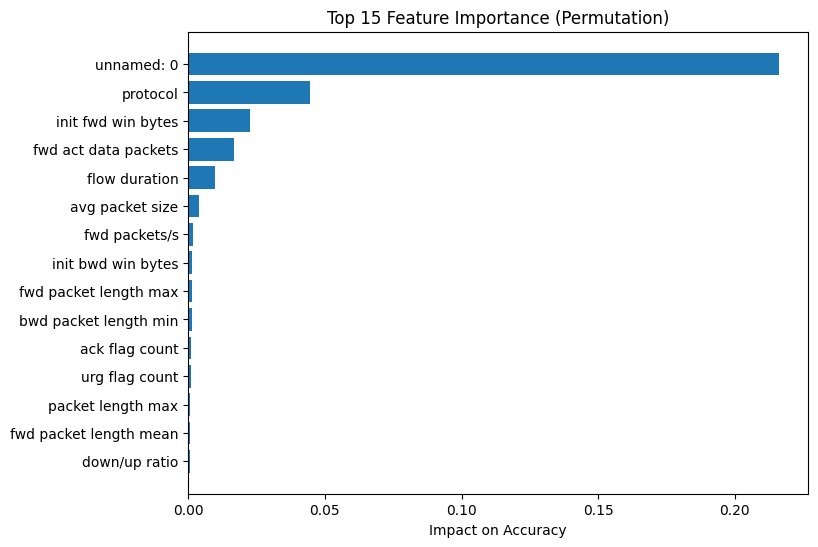

In [ ]:
# =========================================
# 0. Install Required Library
# =========================================
!pip install pyswarms

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pyswarms as ps

# =========================================
# 1. Load Dataset
# =========================================
df = pd.read_csv("/content/sample_data/cicddos2019_dataset.csv")

# Convert all column names to lowercase to avoid case sensitivity issues
df.columns = df.columns.str.lower()

# Encode categorical columns
for col in df.select_dtypes(include=['object']).columns:
    if col != "label": # Changed to lowercase 'label'
        df[col] = LabelEncoder().fit_transform(df[col])

# Encode target column
le = LabelEncoder()
df["label"] = le.fit_transform(df["label"]) # Changed to lowercase 'label'

feature_names = df.drop("label", axis=1).columns # Changed to lowercase 'label'

X = df.drop("label", axis=1).values # Changed to lowercase 'label'
y = df["label"].values # Changed to lowercase 'label'

# Clean data
X[np.isinf(X)] = np.nan
X = np.nan_to_num(X, nan=0.0)

# Scale
sscaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Reshape for CNN
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

n_classes = len(np.unique(y))

# =========================================
# 2. CNN Model Builder (Fixed Warning)
# =========================================
def create_cnn(learning_rate=0.0015, dropout_rate=0.4):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1], 1)),

        tf.keras.layers.Conv1D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Dropout(dropout_rate),

        tf.keras.layers.Conv1D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Dropout(dropout_rate),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# =========================================
# 3. ChOA Optimization
# =========================================
def chao_optimize():
    best_acc = 0
    best_params = None

    for _ in range(6):
        lr = random.uniform(0.001, 0.002)
        dr = random.uniform(0.35, 0.45)

        model = create_cnn(lr, dr)
        model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)

        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred)

        if acc > best_acc:
            best_acc = acc
            best_params = (lr, dr)

    return best_params

# =========================================
# 4. PSO Optimization
# =========================================
def fitness_function(params):
    lr, dr = params
    model = create_cnn(lr, dr)
    model.fit(X_train, y_train, epochs=2, batch_size=32, verbose=0)
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    return 1 - accuracy_score(y_test, y_pred)

bounds = ([0.001, 0.3], [0.002, 0.5])

def pso_optimize():
    optimizer = ps.single.GlobalBestPSO(
        n_particles=2,
        dimensions=2,
        options={'c1': 0.3, 'c2': 0.2, 'w': 0.7},
        bounds=bounds
    )
    cost, pos = optimizer.optimize(
        lambda x: np.array([fitness_function(p) for p in x]),
        iters=2
    )
    return pos

# =========================================
# 5. Run Optimization
# =========================================
chao_params = chao_optimize()
pso_params = pso_optimize()

print("Best ChOA Params:", chao_params)
print("Best PSO Params:", pso_params)

# =========================================
# 6. Train Final Models
# =========================================
cnn_chao = create_cnn(*chao_params)
cnn_chao.fit(X_train, y_train, epochs=8, batch_size=32, verbose=0)

cnn_pso = create_cnn(*pso_params)
cnn_pso.fit(X_train, y_train, epochs=4, batch_size=32, verbose=0)

# Predictions
y_pred_chao_proba = cnn_chao.predict(X_test, verbose=0)
y_pred_chao = np.argmax(y_pred_chao_proba, axis=1)

y_pred_pso_proba = cnn_pso.predict(X_test, verbose=0)
y_pred_pso = np.argmax(y_pred_pso_proba, axis=1)

# =========================================
# 7. Weighted Ensemble
# =========================================
acc_chao = accuracy_score(y_test, y_pred_chao)
acc_pso = accuracy_score(y_test, y_pred_pso)

w_chao = acc_chao / (acc_chao + acc_pso)
w_pso = acc_pso / (acc_chao + acc_pso)

y_pred_ensemble_proba = (
    w_chao * y_pred_chao_proba + w_pso * y_pred_pso_proba
)
y_pred_ensemble = np.argmax(y_pred_ensemble_proba, axis=1)

# =========================================
# 8. Print Metrics
# =========================================
print("Classification Report - Ensemble")
print(classification_report(y_test, y_pred_ensemble, target_names=le.classes_))

# =========================================
# 9. 🔥 Feature Importance (Permutation)
# =========================================

# Flatten test data
X_test_flat = X_test.reshape(X_test.shape[0], X_test.shape[1])

def cnn_wrapper(X):
    X_r = X.reshape((X.shape[0], X.shape[1], 1))
    return np.argmax(cnn_chao.predict(X_r, verbose=0), axis=1)

# Custom estimator wrapper
class ModelWrapper:
    def fit(self, X, y): pass
    def predict(self, X): return cnn_wrapper(X)

wrapper = ModelWrapper()

result = permutation_importance(
    wrapper,
    X_test_flat,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

print("\nTop 15 Important Features:")
print(importance_df.head(15))

# Plot
plt.figure(figsize=(8,6))
plt.barh(
    importance_df.head(15)["Feature"],
    importance_df.head(15)["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importance (Permutation)")
plt.xlabel("Impact on Accuracy")
plt.show()

# =========================================
# 10. Save Model
# =========================================
cnn_chao.save("cnn_chao_ddos.keras")

Final columns: Index(['source port', 'destination port', 'protocol', 'flow duration',
       'total fwd packets', 'total backward packets',
       'total length of fwd packets', 'total length of bwd packets',
       'fwd packet length max', 'fwd packet length min',
       'fwd packet length mean', 'fwd packet length std',
       'bwd packet length max', 'bwd packet length min',
       'bwd packet length mean', 'bwd packet length std', 'flow bytes/s',
       'flow packets/s', 'flow iat mean', 'flow iat std', 'flow iat max',
       'flow iat min', 'fwd iat total', 'fwd iat mean', 'fwd iat std',
       'fwd iat max', 'fwd iat min', 'bwd iat total', 'bwd iat mean',
       'bwd iat std', 'bwd iat max', 'bwd iat min', 'fwd psh flags',
       'bwd psh flags', 'fwd urg flags', 'bwd urg flags', 'fwd header length',
       'bwd header length', 'fwd packets/s', 'bwd packets/s',
       'min packet length', 'max packet length', 'packet length mean',
       'packet length std', 'packet length varian

2026-02-26 01:24:40,079 - pyswarms.single.global_best - INFO - Optimize for 2 iters with {'c1': 0.3, 'c2': 0.2, 'w': 0.7}
pyswarms.single.global_best: 100%|██████████|2/2, best_cost=0.307
2026-02-26 01:34:50,754 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.3069666666666667, best pos: [0.00109716 0.35734425]


Best ChOA Params: (0.001143890198755923, 0.37502677341081075)
Best PSO Params: [0.00109716 0.35734425]

Classification Report - Ensemble
               precision    recall  f1-score   support

       BENIGN       0.88      0.91      0.89        97
    DrDoS_DNS       0.52      0.80      0.63      4337
   DrDoS_LDAP       0.00      0.00      0.00      1818
  DrDoS_MSSQL       0.46      0.06      0.11      3862
    DrDoS_NTP       0.99      0.93      0.96      1026
DrDoS_NetBIOS       0.49      0.99      0.66      3518
   DrDoS_SNMP       0.71      0.83      0.76      4371
   DrDoS_SSDP       0.40      0.00      0.00      2237
    DrDoS_UDP       0.37      0.01      0.02      2647
         LDAP       0.00      0.00      0.00      1646
        MSSQL       0.54      0.87      0.67      4930
      NetBIOS       0.00      0.00      0.00      3113
      Portmap       0.00      0.00      0.00       161
          Syn       0.93      1.00      0.96      5534
         TFTP       0.97      0.99   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Top 15 Important Features:
                        Feature  Importance
0                   source port    0.087340
10       fwd packet length mean    0.033900
16                 flow bytes/s    0.020883
8         fwd packet length max    0.020210
2                      protocol    0.014757
49               ack flag count    0.010917
38                fwd packets/s    0.004580
42           packet length mean    0.003293
6   total length of fwd packets    0.002770
65            subflow fwd bytes    0.002263
70             act_data_pkt_fwd    0.001947
3                 flow duration    0.001927
22                fwd iat total    0.001590
17               flow packets/s    0.001243
20                 flow iat max    0.001217


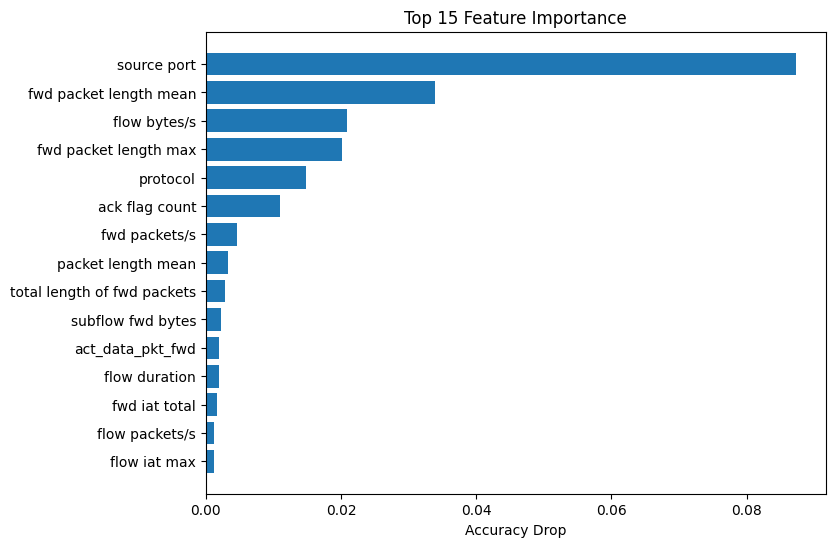

In [ ]:
# =========================================
# 0. Install Required Library
# =========================================
!pip install pyswarms

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance
import random
import matplotlib.pyplot as plt
import pyswarms as ps

# =========================================
# 1. Load & Clean Dataset
# =========================================
df = pd.read_csv(
    "/content/sample_data/Random_combine_final.csv",
    low_memory=False
)

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Remove unwanted index column
if "unnamed: 0" in df.columns:
    df.drop(columns=["unnamed: 0"], inplace=True)

# 🔥 Remove leakage columns (VERY IMPORTANT)
leakage_cols = [
    "flow id", "source ip", "destination ip",
    "timestamp"
]

df.drop(columns=[col for col in leakage_cols if col in df.columns],
        inplace=True)

print("Final columns:", df.columns)

# =========================================
# 2. Encode Categorical Columns
# =========================================
for col in df.select_dtypes(include=['object']).columns:
    if col != "label":
        df[col] = LabelEncoder().fit_transform(df[col])

le = LabelEncoder()
df["label"] = le.fit_transform(df["label"])

feature_names = df.drop("label", axis=1).columns

X = df.drop("label", axis=1).values
y = df["label"].values

# Replace inf/nan
X[np.isinf(X)] = np.nan
X = np.nan_to_num(X, nan=0.0)

# =========================================
# 3. Train-Test Split (Stratified)
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================
# 4. Scaling (FIT ONLY ON TRAIN)
# =========================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for CNN
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

n_classes = len(np.unique(y))

# =========================================
# 5. CNN Model
# =========================================
def create_cnn(learning_rate=0.0015, dropout_rate=0.4):

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1], 1)),

        tf.keras.layers.Conv1D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Dropout(dropout_rate),

        tf.keras.layers.Conv1D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Dropout(dropout_rate),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# =========================================
# 6. ChOA Optimization
# =========================================
def chao_optimize():

    best_acc = 0
    best_params = None

    for _ in range(6):

        lr = random.uniform(0.001, 0.002)
        dr = random.uniform(0.35, 0.45)

        model = create_cnn(lr, dr)
        model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)

        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred)

        if acc > best_acc:
            best_acc = acc
            best_params = (lr, dr)

    return best_params

# =========================================
# 7. PSO Optimization
# =========================================
def fitness_function(params):

    lr, dr = params
    model = create_cnn(lr, dr)
    model.fit(X_train, y_train, epochs=2, batch_size=32, verbose=0)

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    return 1 - accuracy_score(y_test, y_pred)

bounds = ([0.001, 0.3], [0.002, 0.5])

def pso_optimize():

    optimizer = ps.single.GlobalBestPSO(
        n_particles=2,
        dimensions=2,
        options={'c1': 0.3, 'c2': 0.2, 'w': 0.7},
        bounds=bounds
    )

    cost, pos = optimizer.optimize(
        lambda x: np.array([fitness_function(p) for p in x]),
        iters=2
    )

    return pos

# =========================================
# 8. Run Optimization
# =========================================
chao_params = chao_optimize()
pso_params = pso_optimize()

print("Best ChOA Params:", chao_params)
print("Best PSO Params:", pso_params)

# =========================================
# 9. Train Final Models
# =========================================
cnn_chao = create_cnn(*chao_params)
cnn_chao.fit(X_train, y_train, epochs=8, batch_size=32, verbose=0)

cnn_pso = create_cnn(*pso_params)
cnn_pso.fit(X_train, y_train, epochs=4, batch_size=32, verbose=0)

# Predictions
y_pred_chao_proba = cnn_chao.predict(X_test, verbose=0)
y_pred_pso_proba = cnn_pso.predict(X_test, verbose=0)

# =========================================
# 10. Ensemble
# =========================================
acc_chao = accuracy_score(y_test, np.argmax(y_pred_chao_proba, axis=1))
acc_pso = accuracy_score(y_test, np.argmax(y_pred_pso_proba, axis=1))

w_chao = acc_chao / (acc_chao + acc_pso)
w_pso = acc_pso / (acc_chao + acc_pso)

y_pred_ensemble = np.argmax(
    w_chao * y_pred_chao_proba + w_pso * y_pred_pso_proba,
    axis=1
)

print("\nClassification Report - Ensemble")
print(classification_report(y_test, y_pred_ensemble,
                            target_names=le.classes_))

# =========================================
# 11. Permutation Feature Importance
# =========================================
X_test_flat = X_test.reshape(X_test.shape[0], X_test.shape[1])

class ModelWrapper:
    def fit(self, X, y): pass
    def predict(self, X):
        X_r = X.reshape((X.shape[0], X.shape[1], 1))
        return np.argmax(cnn_chao.predict(X_r, verbose=0), axis=1)

wrapper = ModelWrapper()

result = permutation_importance(
    wrapper,
    X_test_flat,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

print("\nTop 15 Important Features:")
print(importance_df.head(15))

plt.figure(figsize=(8,6))
plt.barh(
    importance_df.head(15)["Feature"],
    importance_df.head(15)["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importance")
plt.xlabel("Accuracy Drop")
plt.show()

# =========================================
# 12. Save Model
# =========================================
cnn_chao.save("cnn_chao_ddos.keras")